In [95]:
cultivar_batch_dict = {0: "Granny Smith", 1: "Granny Smith", 2: "Granny Smith", 3: "Granny Smith", 4: "Granny Smith", 5: "Joya", 6: "Envy", 7: "Granny Smith", 8: "Joya", 9: "Golden Delicious", 10: "Joya"}

In [96]:
progression_dates = [3,	5,	7,	10,	14,	21,	28]

In [ ]:
# treatment_1 = {3:"Early", 5:"Early", 7:"Early", 10:"Intermediate", 14:"Intermediate", 21:"Late"}
# treatment_2 = {3:"Early", 5:"Early", 7:"Early", 10:"Intermediate", 14:"Intermediate", 21:"Late"}
# treatment_3 = {3:"Early", 5:"Intermediate", 7:"Intermediate", 10:"Late"}
# treatment_4 = {3:"Early", 5:"Intermediate", 7:"Intermediate", 10:"Late"}
# treatment_5 = {3:"Early", 5:"Early", 7:"Early", 10:"Early", 14:"Early", 21:"Intermediate", 28: "Intermediate"}
# treatment_6 = {3:"Early", 5:"Early", 7:"Early", 10:"Intermediate", 14:"Intermediate", 21:"Late"}
# treatment_7 = {3:"Early", 5:"Early", 7:"Early", 10:"Early", 14:"Early", 21:"Intermediate", 28: "Intermediate"}

treatment_1 = {3:"Early", 5:"Early", 7:"Early", 10:"Intermediate", 14:"Intermediate", 21:"Late", 28:"Late"}
treatment_2 = {3:"Early", 5:"Early", 7:"Early", 10:"Intermediate", 14:"Intermediate", 21:"Late", 28:"Late"}
treatment_3 = {3:"Early", 5:"Intermediate", 7:"Intermediate", 10:"Late", 14:"Late", 21:"Late", 28:"Late"}
treatment_4 = {3:"Early", 5:"Intermediate", 7:"Intermediate", 10:"Late", 14:"Late", 21:"Late", 28:"Late"}
treatment_5 = {3:"Early", 5:"Early", 7:"Early", 10:"Early", 14:"Early", 21:"Intermediate", 28: "Intermediate"}
treatment_6 = {3:"Early", 5:"Early", 7:"Early", 10:"Intermediate", 14:"Intermediate", 21:"Late", 28:"Late"}
treatment_7 = {3:"Early", 5:"Early", 7:"Early", 10:"Early", 14:"Early", 21:"Intermediate", 28: "Intermediate"}


treatment_progressions = {
    1: treatment_1,
    2: treatment_2,
    3: treatment_3,
    4: treatment_4,
    5: treatment_5,
    6: treatment_6,
    7: treatment_7,
}

def dpi_to_progression(treatment, dpi):
    """Map treatment/dpi pairs to progression labels."""
    try:
        if treatment is None or dpi is None:
            return None
        mapping = treatment_progressions.get(int(treatment))
        if mapping is None:
            return None
        return mapping.get(int(dpi))
    except Exception:
        return None


In [98]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import random


def dataset_membership_df(dataset_dir: str | Path) -> pd.DataFrame:
    """Return a dataframe with sample_name plus train/val/test indicator columns."""
    dataset_path = Path(dataset_dir)
    if not any((dataset_path / s).exists() for s in ("train", "val", "test")):
        nested = dataset_path / "dataset"
        if nested.exists():
            dataset_path = nested

    rows: dict[str, dict[str, int]] = {}
    for split in ("train", "val", "test"):
        split_path = dataset_path / split
        if not split_path.exists():
            continue
        for file in split_path.rglob("*"):
            if file.is_file():
                name = file.name
                rows.setdefault(name, {"sample_name": name, "train": 0, "val": 0, "test": 0})
                rows[name][split] = 1

    if not rows:
        return pd.DataFrame(columns=["sample_name", "train", "val", "test"])
    return pd.DataFrame(rows.values()).sort_values("sample_name").reset_index(drop=True)


In [99]:
df = dataset_membership_df("/mnt/slowdisk/public/HIPPA/multiclass_classification")

In [127]:
df.head()
df.to_csv("train_val_test.csv")
len(df)

13324

In [101]:
df[df["val"]==1].head()

,sample_name,train,val,test
144,RGB_04006_241021_000.jpg,0,1,0
145,RGB_04006_241021_090.jpg,0,1,0
146,RGB_04006_241021_180.jpg,0,1,0
147,RGB_04006_241021_270.jpg,0,1,0
148,RGB_04006_241023_000.jpg,0,1,0


In [102]:
def dataset_metadata_df(dataset_dir: str | Path) -> pd.DataFrame:
    """Return dataframe with sample metadata plus train/val/test indicators."""
    dataset_path = Path(dataset_dir)
    if not any((dataset_path / s).exists() for s in ("train", "val", "test")):
        nested = dataset_path / "dataset"
        if nested.exists():
            dataset_path = nested

    def _parse(name: str):
        parts = name.split("_")
        modality = parts[0] if parts else None
        segment = parts[1] if len(parts) > 1 else None
        batch = int(segment[:2]) if segment and segment[:2].isdigit() else None
        treatment = int(segment[2]) if segment and len(segment) > 2 and segment[2].isdigit() else None
        apple_id = segment[3:] if segment and len(segment) > 3 else segment
        date = parts[2] if len(parts) > 2 else None
        angle = parts[3].split(".")[0] if len(parts) > 3 else None
        cultivar = cultivar_batch_dict.get(batch) if 'cultivar_batch_dict' in globals() else None
        return modality, apple_id, batch, treatment, cultivar, date, angle

    rows: dict[str, dict[str, object]] = {}
    for split in ("train", "val", "test"):
        split_path = dataset_path / split
        if not split_path.exists():
            continue
        for file in split_path.rglob("*"):
            if file.is_file():
                name = file.name
                modality, apple_id, batch, treatment, cultivar, date, angle = _parse(name)
                rows.setdefault(
                    name,
                    {
                        "sample_name": name,
                        "apple_id": apple_id,
                        "modality": modality,
                        "batch": batch,
                        "cultivar": cultivar,
                        "treatment": treatment,
                        "date": date,
                        "angle": angle,
                        "train": 0,
                        "val": 0,
                        "test": 0,
                    },
                )
                rows[name][split] = 1

    if not rows:
        return pd.DataFrame(columns=["sample_name", "apple_id", "modality", "batch", "cultivar", "treatment", "date", "dpi", "progression", "angle", "train", "val", "test"])

    df = pd.DataFrame(rows.values())
    df["date_dt"] = pd.to_datetime(df["date"], format="%y%m%d", errors="coerce")

    def date_to_dpi_map(grp: pd.DataFrame) -> dict:
        unique_dates = grp["date_dt"].dropna().drop_duplicates().sort_values().reset_index(drop=True)
        mapping = {}
        for idx, d in enumerate(unique_dates):
            if idx < len(progression_dates):
                mapping[d.strftime("%y%m%d")] = progression_dates[idx]
        return mapping

    df["dpi"] = df.groupby("batch", dropna=False, group_keys=False).apply(
        lambda g: g["date"].map(date_to_dpi_map(g))
    )
    df.drop(columns=["date_dt"], inplace=True)
    df["progression"] = [dpi_to_progression(t, d) for t, d in zip(df["treatment"], df["dpi"])]
    return df[["sample_name", "apple_id", "modality", "batch", "cultivar", "treatment", "date", "dpi", "progression", "angle", "train", "val", "test"]].sort_values("sample_name").reset_index(drop=True)


In [103]:
df_splitted = dataset_metadata_df("/mnt/slowdisk/public/HIPPA/multiclass_classification")
df_splitted

/tmp/ipykernel_39573/2670761978.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["dpi"] = df.groupby("batch", dropna=False, group_keys=False).apply(


,sample_name,apple_id,modality,batch,cultivar,treatment,date,dpi,progression,angle,train,val,test
0,RGB_04000_241021_000.jpg,00,RGB,4,Granny Smith,0,241021,3,None,000,1,0,0
1,RGB_04000_241021_090.jpg,00,RGB,4,Granny Smith,0,241021,3,None,090,1,0,0
2,RGB_04000_241021_180.jpg,00,RGB,4,Granny Smith,0,241021,3,None,180,1,0,0
3,RGB_04000_241021_270.jpg,00,RGB,4,Granny Smith,0,241021,3,None,270,1,0,0
4,RGB_04000_241023_000.jpg,00,RGB,4,Granny Smith,0,241023,5,None,000,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13319,RGB_17823_250702_270.jpg,23,RGB,17,None,8,250702,5,None,270,1,0,0
13320,RGB_17823_250704_000.jpg,23,RGB,17,None,8,250704,7,None,000,1,0,0
13321,RGB_17823_250704_090.jpg,23,RGB,17,None,8,250704,7,None,090,1,0,0
13322,RGB_17823_250704_180.jpg,23,RGB,17,None,8,250704,7,None,180,1,0,0


In [104]:
df_splitted[(df_splitted["treatment"] == 2) & (df_splitted["progression"] == None)].head(10)

,sample_name,apple_id,modality,batch,cultivar,treatment,date,dpi,progression,angle,train,val,test


In [105]:
def check_split_leakage(meta_df: pd.DataFrame | None = None, dataset_dir: str | Path | None = None) -> pd.DataFrame:
    """Detect apples (batch+treatment+apple_id) that land in more than one split.

    Pass either a precomputed dataframe from dataset_metadata_df or a dataset_dir to load one.
    Returns a dataframe of violations with the splits each apple touches.
    """
    if meta_df is None:
        if dataset_dir is None:
            raise ValueError("Provide either meta_df or dataset_dir")
        meta_df = dataset_metadata_df(dataset_dir)
    if meta_df.empty:
        return pd.DataFrame(columns=["batch", "treatment", "apple_id", "splits", "file_count"])

    def splits_present(group: pd.DataFrame) -> list[str]:
        return [s for s in ("train", "val", "test") if group[s].any()]
    violations = []
    for (batch, treatment, apple_id), group in meta_df.groupby(["batch", "treatment", "apple_id"], dropna=False):
        splits = splits_present(group)
        if len(splits) > 1:
            violations.append(
                {
                    "batch": batch,
                    "treatment": treatment,
                    "apple_id": apple_id,
                    "splits": splits,
                    "file_count": len(group),
                }
            )

    if not violations:
        print("No split leakage detected: each apple appears in a single split across train/val/test.")
        return pd.DataFrame(columns=["batch", "treatment", "apple_id", "splits", "file_count"])
    print(f"Found {len(violations)} apples spanning multiple splits.")
    return pd.DataFrame(violations).sort_values(["batch", "treatment", "apple_id"]).reset_index(drop=True)


In [106]:
df_splitted = dataset_metadata_df("/mnt/slowdisk/public/HIPPA/multiclass_classification")  # adjust as needed
leaks = check_split_leakage(meta_df=df_splitted)
leaks


No split leakage detected: each apple appears in a single split across train/val/test.


/tmp/ipykernel_39573/2670761978.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df["dpi"] = df.groupby("batch", dropna=False, group_keys=False).apply(


,batch,treatment,apple_id,splits,file_count


In [107]:
def summarize_splits(meta_df: pd.DataFrame) -> dict:
    """Return split totals and split-by-treatment totals from metadata dataframe."""
    if meta_df.empty:
        return {"split_counts": {}, "treatment_split_counts": pd.DataFrame()}

    split_counts = {split: int(meta_df[split].sum()) for split in ("train", "val", "test")}
    treatment_split_counts = (
        meta_df.groupby("treatment")[['train', 'val', 'test']].sum().astype(int).sort_index()
    )
    return {"split_counts": split_counts, "treatment_split_counts": treatment_split_counts}



summary = summarize_splits(df_splitted)
summary["split_counts"], summary["treatment_split_counts"]


({'train': 9240, 'val': 2052, 'test': 2032},
            train  val  test
 treatment                  
 0           2428  548   520
 1           1136  248   248
 2           1244  256   276
 3            544  132    92
 4            600  132   132
 5            960  212   268
 6            448   84    84
 7            884  228   208
 8            996  212   204)

In [108]:
def random_apple_progression(meta_df: pd.DataFrame, seed: int = 123) -> pd.DataFrame:
    """Pick a random apple/treatment/angle and show its samples across dates."""
    if meta_df.empty:
        return pd.DataFrame()
    rng = random.Random(seed)
    key_cols = ["apple_id", "treatment", "angle"]
    groups = list(meta_df.groupby(key_cols, dropna=False))
    (apple_id, treatment, angle), group = rng.choice(groups)
    out = group.sort_values("date")[
        [
            "sample_name", "apple_id", "treatment", "angle", "date", "dpi", "progression", "train", "val", "test"
        ]
    ].reset_index(drop=True)
    print(f"Selected apple_id={apple_id}, treatment={treatment}, angle={angle} across {len(out)} samples")
    return out


# Example usage:
random_apple_progression(df_splitted)


Selected apple_id=01, treatment=4, angle=090 across 9 samples


,sample_name,apple_id,treatment,angle,date,dpi,progression,train,val,test
0,RGB_07401_241202_090.jpg,01,4,090,241202,3,Early,1,0,0
1,RGB_08401_241202_090.jpg,01,4,090,241202,3,Early,1,0,0
2,RGB_07401_241204_090.jpg,01,4,090,241204,5,Intermediate,1,0,0
3,RGB_08401_241204_090.jpg,01,4,090,241204,5,Intermediate,1,0,0
4,RGB_07401_241206_090.jpg,01,4,090,241206,7,Intermediate,1,0,0
5,RGB_08401_241206_090.jpg,01,4,090,241206,7,Intermediate,1,0,0
6,RGB_13401_250505_090.jpg,01,4,090,250505,3,Early,1,0,0
7,RGB_13401_250507_090.jpg,01,4,090,250507,5,Intermediate,1,0,0
8,RGB_13401_250509_090.jpg,01,4,090,250509,7,Intermediate,1,0,0


In [124]:
df_splitted[(df_splitted["treatment"] == 3) & (df_splitted["angle"] == "000")].head(5)

,sample_name,apple_id,modality,batch,cultivar,treatment,date,dpi,progression,angle,train,val,test
5520,RGB_10300_250217_000.jpg,00,RGB,10,Joya,3,250217,3,Early,000,1,0,0
5524,RGB_10300_250219_000.jpg,00,RGB,10,Joya,3,250219,5,Intermediate,000,1,0,0
5528,RGB_10300_250224_000.jpg,00,RGB,10,Joya,3,250224,10,Late,000,1,0,0
5532,RGB_10300_250228_000.jpg,00,RGB,10,Joya,3,250228,14,None,000,1,0,0
5536,RGB_10300_250307_000.jpg,00,RGB,10,Joya,3,250307,21,None,000,1,0,0


In [110]:
PROJ_NAME = "/mnt/slowdisk/public/HIPPA"
TASK = "multiclass_classification"
DATA_DIR = "/mnt/slowdisk/public/HIPPA"

In [111]:
def batch_treatment_progression(meta_df: pd.DataFrame) -> pd.DataFrame:
    """Return progression order per (batch, treatment) where earliest date=1, next=2, etc."""
    if meta_df.empty:
        return pd.DataFrame()
    df = meta_df.dropna(subset=["batch", "treatment", "date"]).copy()
    df["date_dt"] = pd.to_datetime(df["date"], format="%y%m%d", errors="coerce")
    df = df.dropna(subset=["date_dt"])
    if df.empty:
        return pd.DataFrame()

    records = []
    for (batch, treatment), grp in df.groupby(["batch", "treatment"], dropna=False):
        dates = grp["date_dt"].drop_duplicates().sort_values().reset_index(drop=True)
        cultivar = grp.get("cultivar")
        cultivar_name = cultivar.iloc[0] if cultivar is not None and not cultivar.dropna().empty else None
        for idx, d in enumerate(dates, start=1):
            dpi_values = grp.loc[grp["date_dt"] == d, "dpi"].dropna().unique() if "dpi" in grp else []
            dpi = int(dpi_values[0]) if len(dpi_values) > 0 else (progression_dates[idx - 1] if idx - 1 < len(progression_dates) else None)
            stage = dpi_to_progression(treatment, dpi)
            records.append({"batch": batch, "cultivar": cultivar_name, "treatment": treatment, "date": d.strftime("%y%m%d"), "dpi": dpi, "progression_stage": stage, "progression": idx, "samples": int(grp[grp["date_dt"] == d].shape[0])})
    if not records:
        return pd.DataFrame()
    return pd.DataFrame(records).sort_values(["batch", "treatment", "progression"]).reset_index(drop=True)


# Example usage:
progression_df = batch_treatment_progression(df_splitted)
progression_df


,batch,cultivar,treatment,date,dpi,progression_stage,progression,samples
0,4,Granny Smith,0,241021,3,None,1,96
1,4,Granny Smith,0,241023,5,None,2,96
2,4,Granny Smith,0,241025,7,None,3,96
3,4,Granny Smith,0,241028,10,None,4,96
4,4,Granny Smith,0,241031,14,None,5,96
...,...,...,...,...,...,...,...,...
136,17,None,7,250707,10,Early,4,96
137,17,None,7,250711,14,Early,5,96
138,17,None,8,250630,3,None,1,96
139,17,None,8,250702,5,None,2,96


In [112]:
progression_df[progression_df["treatment"] == 2].head(10)

,batch,cultivar,treatment,date,dpi,progression_stage,progression,samples
17,7,Granny Smith,2,241202,3,Early,1,96
18,7,Granny Smith,2,241204,5,Early,2,96
19,7,Granny Smith,2,241206,7,Early,3,96
20,7,Granny Smith,2,241209,10,Intermediate,4,96
21,7,Granny Smith,2,241213,14,Intermediate,5,96
37,8,Joya,2,241202,3,Early,1,96
38,8,Joya,2,241204,5,Early,2,96
39,8,Joya,2,241206,7,Early,3,96
40,8,Joya,2,241209,10,Intermediate,4,96
41,8,Joya,2,241213,14,Intermediate,5,96


In [113]:
progression_df[(progression_df["treatment"] == 2) ].head(10)

,batch,cultivar,treatment,date,dpi,progression_stage,progression,samples
17,7,Granny Smith,2,241202,3,Early,1,96
18,7,Granny Smith,2,241204,5,Early,2,96
19,7,Granny Smith,2,241206,7,Early,3,96
20,7,Granny Smith,2,241209,10,Intermediate,4,96
21,7,Granny Smith,2,241213,14,Intermediate,5,96
37,8,Joya,2,241202,3,Early,1,96
38,8,Joya,2,241204,5,Early,2,96
39,8,Joya,2,241206,7,Early,3,96
40,8,Joya,2,241209,10,Intermediate,4,96
41,8,Joya,2,241213,14,Intermediate,5,96


In [114]:
def summarize_progression(progression_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize progression counts per treatment: how many batches have N rounds."""
    if progression_df.empty:
        return pd.DataFrame()
    summary = progression_df.groupby(['treatment', 'progression']).size().unstack(fill_value=0)
    summary = summary.sort_index().astype(int)
    summary.index.name = 'treatment'
    return summary

# Example usage:
progression_df = batch_treatment_progression(df_splitted)
summarize_progression(progression_df)


progression,1,2,3,4,5,6,7
treatment,,,,,,,
0,8,8,7,5,5,3,1
1,3,3,3,3,3,2,0
2,4,4,4,3,3,1,0
3,2,2,2,1,1,0,0
4,3,3,3,0,0,0,0
5,3,3,3,2,2,1,1
6,1,1,1,1,1,1,1
7,3,3,3,2,2,1,0
8,5,5,4,1,0,0,0


In [115]:
def cultivar_treatment_progression(meta_df: pd.DataFrame) -> pd.DataFrame:
    """Return progression order per (cultivar, treatment) where earliest date=1."""
    if meta_df.empty:
        return pd.DataFrame()
    df = meta_df.dropna(subset=["cultivar", "treatment", "date"]).copy()
    df["date_dt"] = pd.to_datetime(df["date"], format="%y%m%d", errors="coerce")
    df = df.dropna(subset=["date_dt"])
    if df.empty:
        return pd.DataFrame()

    records = []
    for (cultivar, treatment), grp in df.groupby(["cultivar", "treatment"], dropna=False):
        dates = grp["date_dt"].drop_duplicates().sort_values().reset_index(drop=True)
        batches = sorted(grp["batch"].dropna().unique()) if "batch" in grp else []
        for idx, d in enumerate(dates, start=1):
            dpi_values = grp.loc[grp["date_dt"] == d, "dpi"].dropna().unique() if "dpi" in grp else []
            dpi = int(dpi_values[0]) if len(dpi_values) > 0 else (progression_dates[idx - 1] if idx - 1 < len(progression_dates) else None)
            stage = dpi_to_progression(treatment, dpi)
            records.append({
                "cultivar": cultivar,
                "treatment": treatment,
                "date": d.strftime("%y%m%d"),
                "dpi": dpi,
                "progression_stage": stage,
                "progression": idx,
                "samples": int(grp[grp["date_dt"] == d].shape[0]),
                "batches": batches,
            })
    if not records:
        return pd.DataFrame()
    return pd.DataFrame(records).sort_values(["cultivar", "treatment", "progression"]).reset_index(drop=True)


# Example usage:
cultivar_progression_df = cultivar_treatment_progression(df_splitted)
cultivar_progression_df


,cultivar,treatment,date,dpi,progression_stage,progression,samples,batches
0,Granny Smith,0,241021,3,None,1,96,"[4, 7]"
1,Granny Smith,0,241023,5,None,2,96,"[4, 7]"
2,Granny Smith,0,241025,7,None,3,96,"[4, 7]"
3,Granny Smith,0,241028,10,None,4,96,"[4, 7]"
4,Granny Smith,0,241031,14,None,5,96,"[4, 7]"
...,...,...,...,...,...,...,...,...
82,Joya,7,250314,28,Intermediate,6,92,[10]
83,Joya,8,250217,3,None,1,96,[10]
84,Joya,8,250219,5,None,2,96,[10]
85,Joya,8,250224,10,None,3,96,[10]


In [116]:
def summarize_cultivar_progression(progression_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize progression counts with explicit treatment labels per cultivar."""
    if progression_df.empty:
        return pd.DataFrame()
    summary = progression_df.groupby(["cultivar", "treatment", "progression"]).size().reset_index(name="count")
    summary["treatment_label"] = summary["treatment"].apply(lambda t: f"treatment {t}")
    pivot = summary.pivot_table(
        index=["cultivar", "treatment", "treatment_label"],
        columns="progression",
        values="count",
        fill_value=0,
    ).sort_index()
    pivot.columns = [f"progression_{int(c)}" for c in pivot.columns]
    return pivot.astype(int)


# Example usage (two cultivars expected):
cultivar_progression_df = cultivar_treatment_progression(df_splitted)
summarize_cultivar_progression(cultivar_progression_df)


progression_1  progression_2  \
cultivar     treatment treatment_label                                 
Granny Smith 0         treatment 0                  1              1   
             1         treatment 1                  1              1   
             2         treatment 2                  1              1   
             4         treatment 4                  1              1   
Joya         0         treatment 0                  1              1   
             1         treatment 1                  1              1   
             2         treatment 2                  1              1   
             3         treatment 3                  1              1   
             4         treatment 4                  1              1   
             5         treatment 5                  1              1   
             6         treatment 6                  1              1   
             7         treatment 7                  1              1   
             8         treatment 8                  1              1   

                                        progression_3  progression_4  \
cultivar     treatment treatment_label                                 
Granny Smith 0         treatment 0                  1              1   
             1         treatment 1                  1              1   
             2         treatment 2                  1              1   
             4         treatment 4                  1              0   
Joya         0         treatment 0                  1              1   
             1         treatment 1                  1              1   
             2         treatment 2                  1              1   
             3         treatment 3                  1              1   
             4         treatment 4                  1              0   
             5         treatment 5                  1              1   
             6         treatment 6                  1              1   
             7         treatment 7                  1              1   
             8         treatment 8                  1              1   

                                        progression_5  progression_6  \
cultivar     treatment treatment_label                                 
Granny Smith 0         treatment 0                  1              1   
             1         treatment 1                  1              1   
             2         treatment 2                  1              0   
             4         treatment 4                  0              0   
Joya         0         treatment 0                  1              1   
             1         treatment 1                  1              1   
             2         treatment 2                  1              1   
             3         treatment 3                  1              0   
             4         treatment 4                  0              0   
             5         treatment 5                  1              1   
             6         treatment 6                  1              1   
             7         treatment 7                  1              1   
             8         treatment 8                  0              0   

                                        progression_7  progression_8  \
cultivar     treatment treatment_label                                 
Granny Smith 0         treatment 0                  1              1   
             1         treatment 1                  0              0   
             2         treatment 2                  0              0   
             4         treatment 4                  0              0   
Joya         0         treatment 0                  1              1   
             1         treatment 1                  0              0   
             2         treatment 2                  1              1   
             3         treatment 3                  0              0   
             4         treatment 4                  0              0   
     

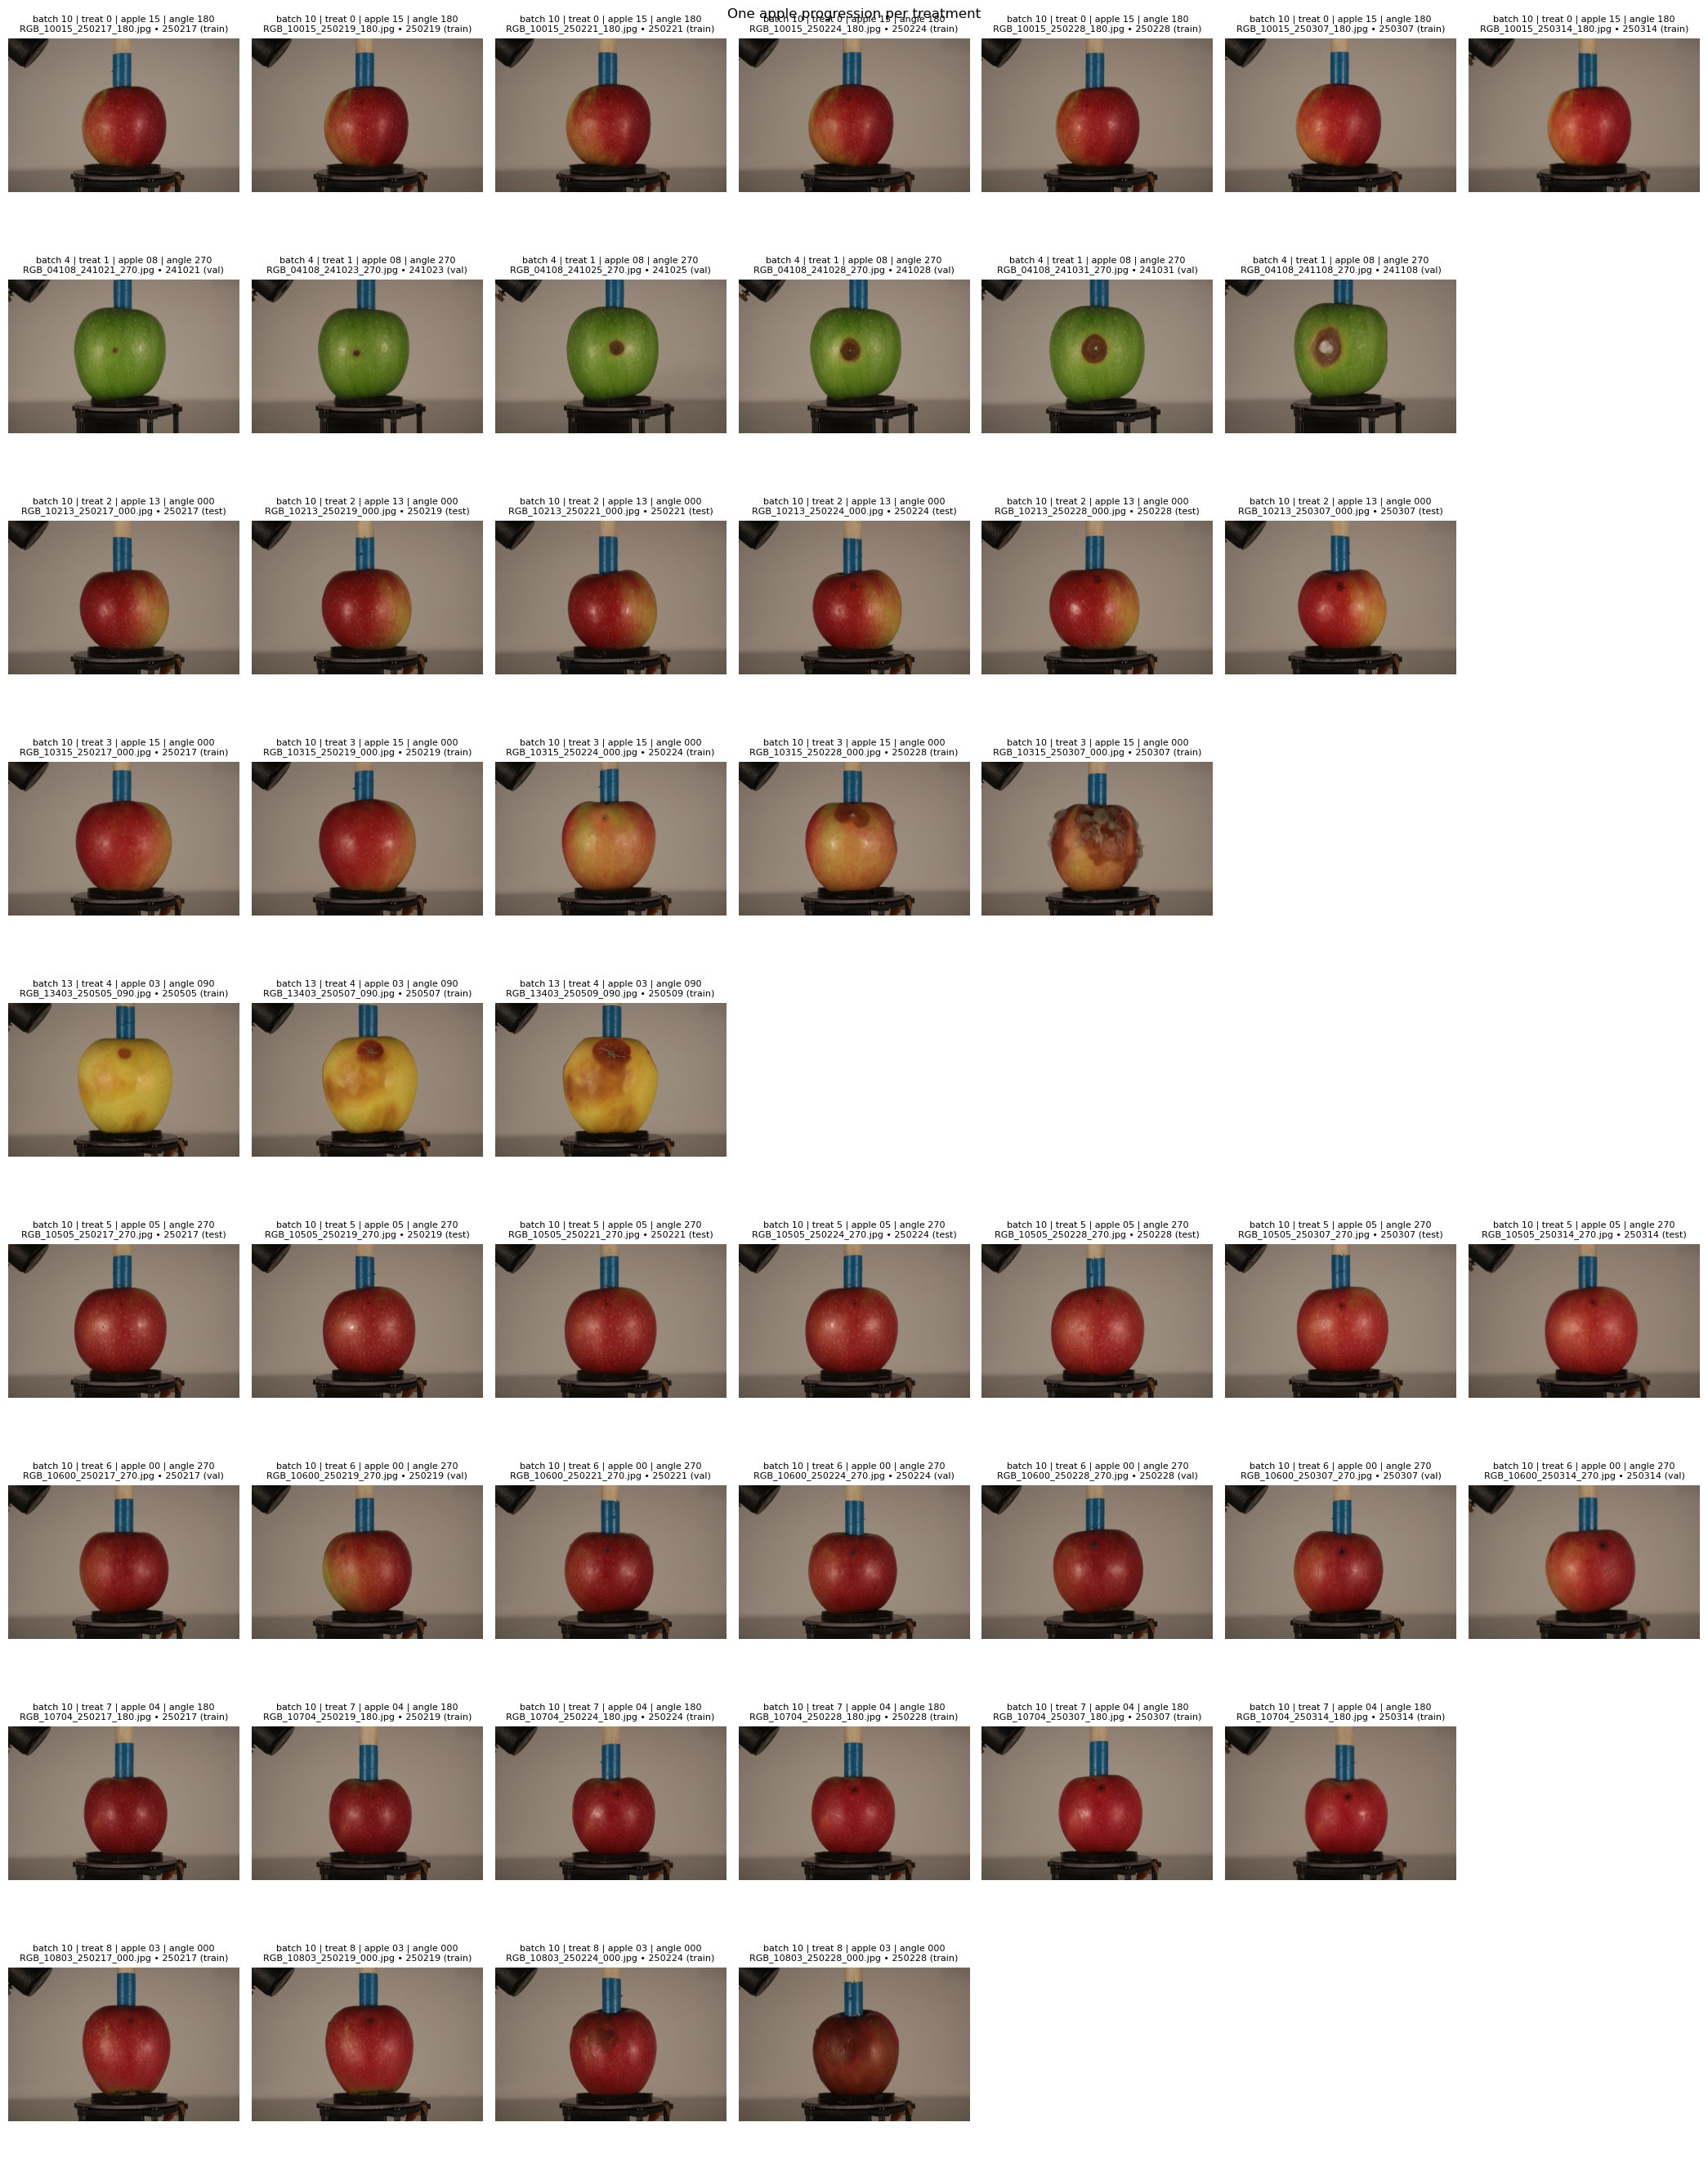

In [117]:
def plot_apple_progression_images(meta_df: pd.DataFrame, dataset_dir: str | Path, treatments=None, seed: int = 42, show: bool = True):
    """Show one apple (batch+apple_id+angle) per treatment, sorted by treatment."""
    if meta_df.empty:
        print("No data to plot.")
        return None
    dataset_path = Path(dataset_dir)
    if not any((dataset_path / s).exists() for s in ("train", "val", "test")) and (dataset_path / "dataset").exists():
        dataset_path = dataset_path / "dataset"

    treatments = sorted(treatments) if treatments is not None else sorted(meta_df["treatment"].dropna().unique())
    rng = random.Random(seed)

    selections = []
    for t in treatments:
        grp = meta_df[meta_df["treatment"] == t]
        if grp.empty:
            continue
        candidates = []
        for (batch, aid, ang), g in grp.groupby(["batch", "apple_id", "angle"], dropna=False):
            candidates.append((len(g), g["date"].nunique(), rng.random(), batch, aid, ang, g))
        if not candidates:
            continue
        candidates.sort(reverse=True, key=lambda x: (x[0], x[1], x[2]))
        _, _, _, batch, aid, ang, chosen = candidates[0]
        subset = chosen.sort_values("date").copy()
        subset["split"] = subset[["train", "val", "test"]].idxmax(axis=1)
        subset["_key"] = t
        selections.append(subset)

    if not selections:
        print("No matching samples to plot.")
        return None

    max_cols = max(len(s) for s in selections)
    rows = len(selections)
    fig, axes = plt.subplots(rows, max_cols, figsize=(3 * max_cols, 3 * rows))
    if rows == 1:
        axes = [axes]
    for row_idx, subset in enumerate(sorted(selections, key=lambda s: s.iloc[0]["_key"])):
        for col_idx in range(max_cols):
            ax = axes[row_idx][col_idx] if rows > 1 else axes[col_idx]
            if col_idx >= len(subset):
                ax.axis("off")
                continue
            row = subset.iloc[col_idx]
            split = row["split"]
            class_dir = dataset_path / split / f"class_{int(row['treatment'])}"
            candidate = class_dir / row["sample_name"]
            if candidate.exists():
                img = plt.imread(candidate)
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, "Missing\nimage", ha="center", va="center")
            label = f"batch {int(row['batch'])} | treat {int(row['treatment'])} | apple {row['apple_id']} | angle {row['angle']}"
            ax.set_title(f"{label}\n{row['sample_name']} • {row['date']} ({split})", fontsize=8)
            ax.axis("off")
    fig.suptitle("One apple progression per treatment")
    fig.tight_layout()
    if show:
        plt.show()
        return None
    return fig


# Example usage:
plot_apple_progression_images(df_splitted, Path(PROJ_NAME)/TASK, treatments=range(9))


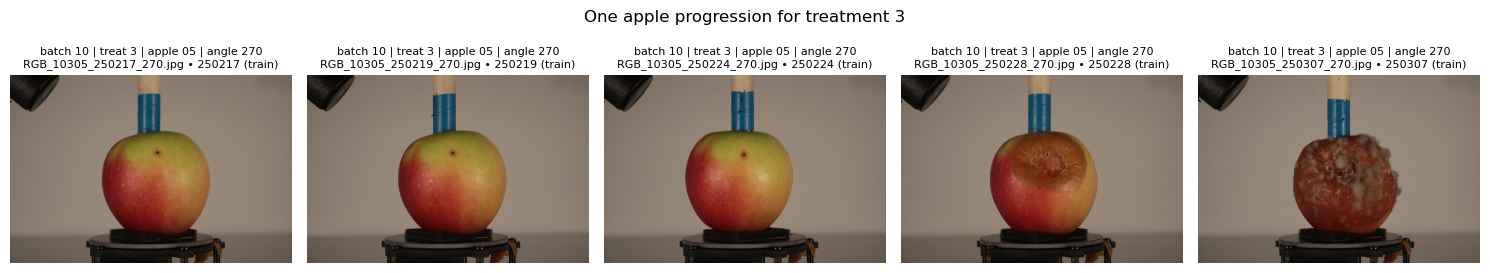

In [118]:
def plot_selected_treatment_progression(meta_df: pd.DataFrame, dataset_dir: str | Path, treatment: int | float | str, seed: int | None = 42, show: bool = True):
    """Show one apple progression for a chosen treatment."""
    if meta_df.empty:
        print("No data to plot.")
        return None
    if treatment is None:
        print("Please provide a treatment id to plot.")
        return None
    try:
        typed_treatment = meta_df["treatment"].dtype.type(treatment)
    except Exception:
        typed_treatment = treatment

    dataset_path = Path(dataset_dir)
    if not any((dataset_path / s).exists() for s in ("train", "val", "test")) and (dataset_path / "dataset").exists():
        dataset_path = dataset_path / "dataset"

    rng = random.Random(seed)
    grp = meta_df[meta_df["treatment"] == typed_treatment]
    if grp.empty:
        print(f"No samples found for treatment {typed_treatment}.")
        return None

    candidates = []
    for (batch, aid, ang), g in grp.groupby(["batch", "apple_id", "angle"], dropna=False):
        candidates.append((len(g), g["date"].nunique(), rng.random(), batch, aid, ang, g))
    if not candidates:
        print(f"No samples found for treatment {typed_treatment}.")
        return None
    candidates.sort(reverse=True, key=lambda x: (x[0], x[1], x[2]))
    _, _, _, batch, aid, ang, chosen = candidates[0]
    subset = chosen.sort_values("date").copy()
    subset["split"] = subset[["train", "val", "test"]].idxmax(axis=1)

    max_cols = len(subset)
    fig, axes = plt.subplots(1, max_cols, figsize=(3 * max_cols, 3))
    import numpy as np
    axes = np.atleast_2d(axes)
    for col_idx in range(max_cols):
        ax = axes[0, col_idx]
        row = subset.iloc[col_idx]
        split = row["split"]
        class_dir = dataset_path / split / f"class_{int(row['treatment'])}"
        candidate = class_dir / row["sample_name"]
        if candidate.exists():
            img = plt.imread(candidate)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "Missing\nimage", ha="center", va="center")
        label = f"batch {int(row['batch'])} | treat {int(row['treatment'])} | apple {row['apple_id']} | angle {row['angle']}"
        ax.set_title(f"{label}\n{row['sample_name']} • {row['date']} ({split})", fontsize=8)
        ax.axis("off")
    fig.suptitle(f"One apple progression for treatment {typed_treatment}")
    fig.tight_layout()
    if show:
        plt.show()
        return None
    return fig


# Example usage:
plot_selected_treatment_progression(df_splitted, Path(PROJ_NAME)/TASK, treatment=3, seed=None)


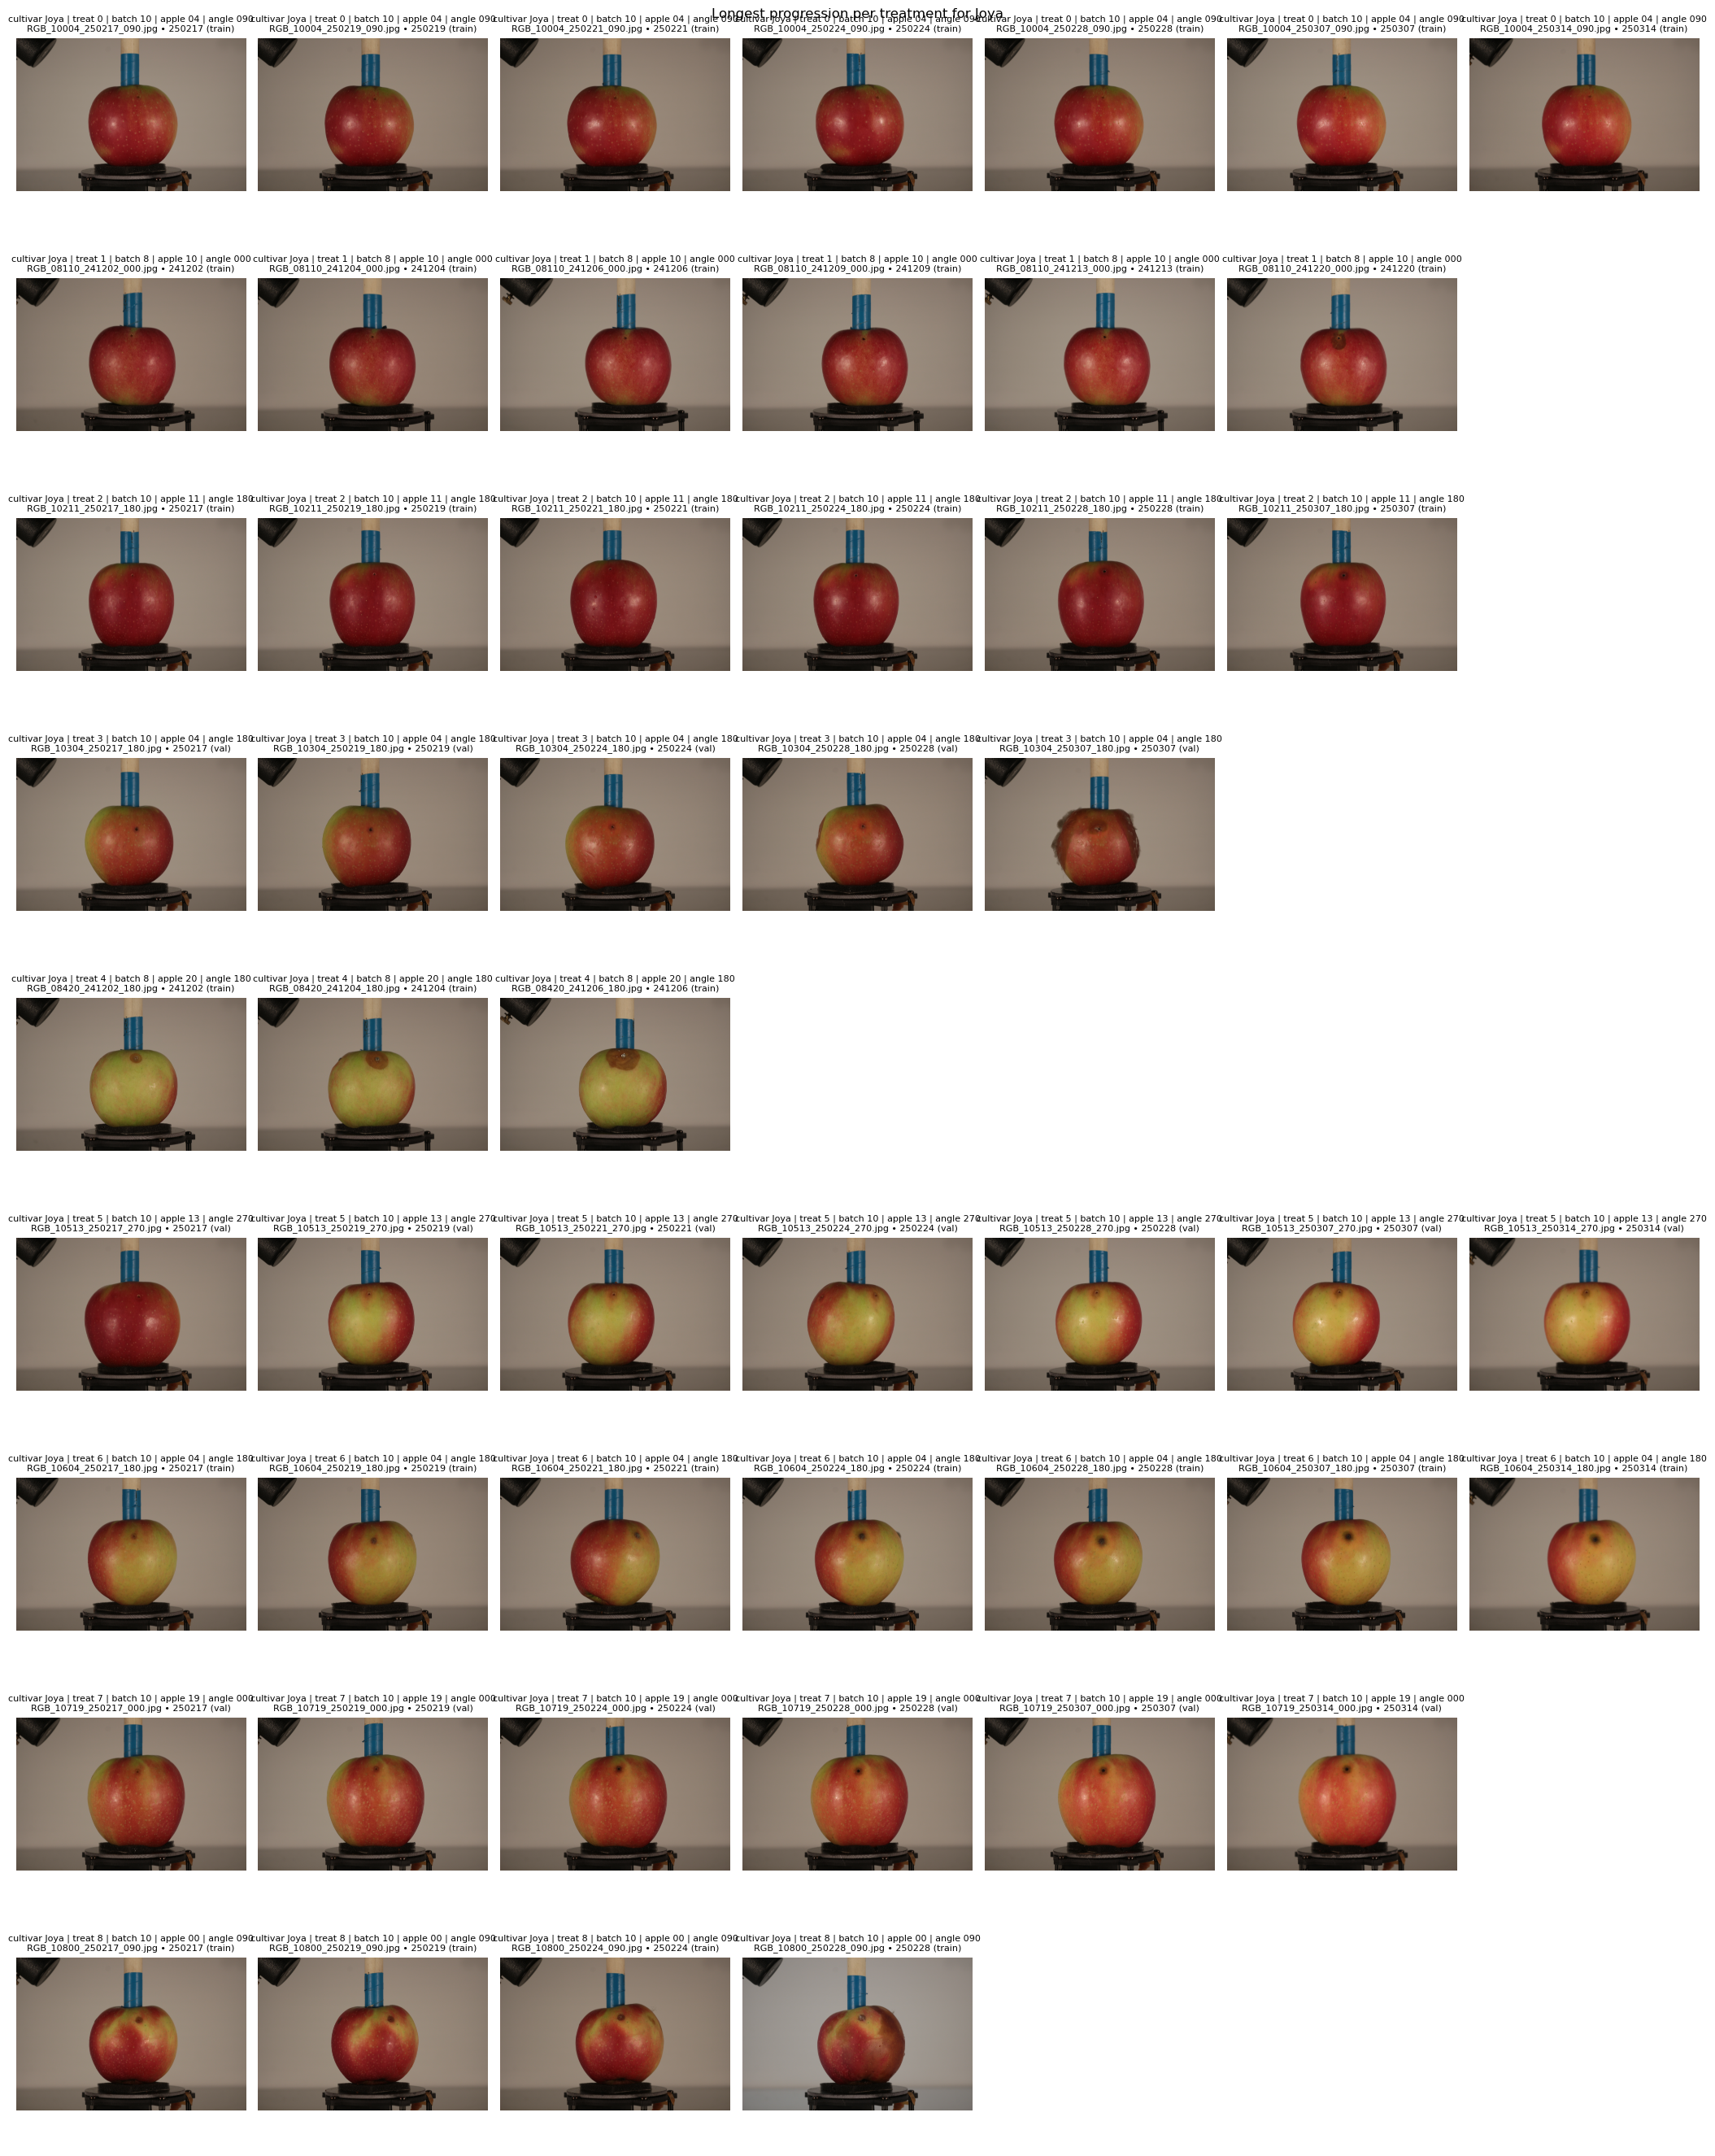

In [119]:
def plot_cultivar_progression(meta_df: pd.DataFrame, dataset_dir: str | Path, cultivar=None, treatments=None, seed: int | None = 42, show: bool = True):
    """Plot the longest available apple progression per treatment, optionally filtered by cultivar."""
    if meta_df.empty:
        print("No data to plot.")
        return None
    df = meta_df.copy()
    if cultivar is not None:
        df = df[df["cultivar"] == cultivar]
    if df.empty:
        print(f"No data found for cultivar {cultivar}.")
        return None

    dataset_path = Path(dataset_dir)
    if not any((dataset_path / s).exists() for s in ("train", "val", "test")) and (dataset_path / "dataset").exists():
        dataset_path = dataset_path / "dataset"

    if treatments is None:
        treatments = sorted(df["treatment"].dropna().unique())
    else:
        if not isinstance(treatments, (list, tuple, set)):
            treatments = [treatments]
        treatments = sorted(treatments)
    rng = random.Random(seed)

    selections = []
    for t in treatments:
        grp = df[df["treatment"] == t]
        if grp.empty:
            continue
        candidates = []
        for (batch, aid, ang), g in grp.groupby(["batch", "apple_id", "angle"], dropna=False):
            candidates.append((g["date"].nunique(), g.shape[0], rng.random(), batch, aid, ang, g))
        if not candidates:
            continue
        candidates.sort(reverse=True, key=lambda x: (x[0], x[1], x[2]))
        length, _, _, batch, aid, ang, chosen = candidates[0]
        subset = chosen.sort_values("date").copy()
        subset["split"] = subset[["train", "val", "test"]].idxmax(axis=1)
        subset["_key"] = [(t, length)] * len(subset)
        subset["_batch"] = batch
        subset["_angle"] = ang
        subset["_apple"] = aid
        selections.append(subset)

    if not selections:
        print("No matching samples to plot.")
        return None

    max_cols = max(len(s) for s in selections)
    rows = len(selections)
    fig, axes = plt.subplots(rows, max_cols, figsize=(3 * max_cols, 3 * rows))
    if rows == 1:
        axes = [axes]
    for row_idx, subset in enumerate(sorted(selections, key=lambda s: s.iloc[0]["_key"])):
        t, length = subset.iloc[0]["_key"]
        for col_idx in range(max_cols):
            ax = axes[row_idx][col_idx] if rows > 1 else axes[col_idx]
            if col_idx >= len(subset):
                ax.axis("off")
                continue
            row = subset.iloc[col_idx]
            split = row["split"]
            class_dir = dataset_path / split / f"class_{int(row['treatment'])}"
            candidate = class_dir / row["sample_name"]
            if candidate.exists():
                img = plt.imread(candidate)
                ax.imshow(img)
            else:
                ax.text(0.5, 0.5, "Missing\nimage", ha="center", va="center")
            label = f"cultivar {row['cultivar']} | treat {int(row['treatment'])} | batch {int(row['_batch'])} | apple {row['_apple']} | angle {row['_angle']}"
            ax.set_title(f"{label}\n{row['sample_name']} • {row['date']} ({split})", fontsize=8)
            ax.axis("off")
    title_cultivar = cultivar if cultivar is not None else "all cultivars"
    fig.suptitle(f"Longest progression per treatment for {title_cultivar}")
    fig.tight_layout()
    if show:
        plt.show()
        return None
    return fig


# Example usage:
plot_cultivar_progression(df_splitted, Path(PROJ_NAME)/TASK, cultivar="Joya", treatments=None, seed=None)
